Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating Industry Standard GARCH & EGARCH (Window: 252, Refit: 21 days)...


Out-of-sample GARCH/EGARCH generation complete.
Generating rolling regimes and smoothed targets...
Generating lag features for: [1, 2, 3, 5, 10] days...
Preparing data. Target variable: Target_Smooth_10d
Training Samples: 4772 | Testing Samples: 1194
Training XGBoost Classifier...



Model Evaluation on Unseen Test Data (Chronological)
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.94      0.92      0.93      1078
Class 1 (Elevated)       0.00      0.00      0.00        22
   Class 2 (Shock)       0.38      0.47      0.42        94

          accuracy                           0.87      1194
         macro avg       0.44      0.46      0.45      1194
      weighted avg       0.88      0.87      0.87      1194



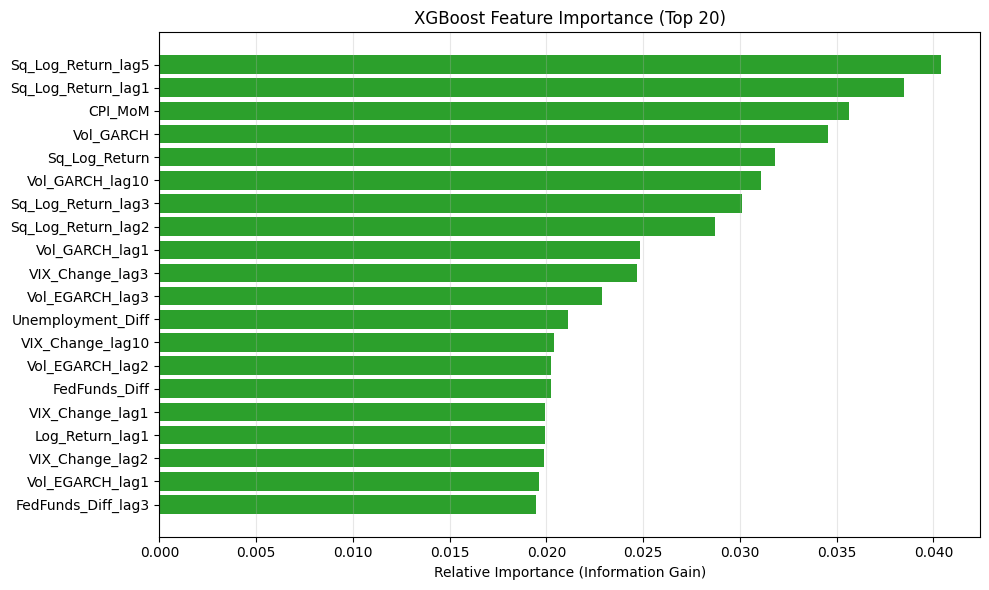

In [1]:
# 03_baseline_xgboost.ipynb

# 1. Imports
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.src_bak import data_loader, features, volatility, regimes, models_xgb

# 2. The Complete Modular Pipeline Execution
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)

# Generate ML-Safe GARCH
garch_df = volatility.generate_expanding_garch(stat_df, window_size=252)

# Generate Targets
regime_df = regimes.generate_smoothed_targets(
    garch_df, lower_quant=0.85, upper_quant=0.95, floor=0.0
)

# Generate Lags for XGBoost
cols_to_lag = [
    'Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
    'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff'
]
final_df = features.create_lags(regime_df, feature_cols=cols_to_lag)

# 3. Train and Evaluate
model, feature_names, X_test, y_test = models_xgb.train_xgboost_baseline(final_df)

# 4. Feature Importance
models_xgb.plot_feature_importance(model, feature_names)

==================================================
Model Evaluation on Unseen Test Data (Chronological)
==================================================
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.95      0.81      0.88      1037
Class 1 (Elevated)       0.16      0.40      0.23        63
   Class 2 (Shock)       0.43      0.70      0.53        94

          accuracy                           0.78      1194
         macro avg       0.51      0.64      0.55      1194
      weighted avg       0.87      0.78      0.82      1194



In [2]:
# In 03_baseline_xgboost.ipynb
from src.src_bak import data_loader, features, volatility, regimes, models_xgb

# 1. Core Pipeline
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)
garch_df = volatility.generate_expanding_garch(stat_df, window_size=252)
regime_df = regimes.generate_smoothed_targets(garch_df, lower_quant=0.85, upper_quant=0.95, floor=0.0)

# 2. Lag Engineering
cols_to_lag = ['Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
               'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff']
final_df = features.create_lags(regime_df, feature_cols=cols_to_lag)

# 3. Run the Walk-Forward Validation (4 splits = 20% chunks)
final_model, feature_names = models_xgb.train_xgb_walk_forward(final_df, n_splits=4)

Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating Industry Standard GARCH & EGARCH (Window: 252, Refit: 21 days)...


Out-of-sample GARCH/EGARCH generation complete.
Generating rolling regimes and smoothed targets...
Generating lag features for: [1, 2, 3, 5, 10] days...
Starting expanding-window Walk-Forward Validation (4 splits)...

--- Fold 1 ---
  Training on index 0 to 1193 (Samples: 1193)
  Testing on index 1193 to 2386 (Samples: 1193)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.87      1.00      0.93      1036
Class 1 (Elevated)       0.00      0.00      0.00        33
   Class 2 (Shock)       0.00      0.00      0.00       124

          accuracy                           0.87      1193
         macro avg       0.29      0.33      0.31      1193
      weighted avg       0.75      0.87      0.81      1193


--- Fold 2 ---
  Training on index 0 to 2386 (Samples: 2386)
  Testing on index 2386 to 3579 (Samples: 1193)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.97      0.99      0.98      1141
Class 1 (Elevated)       0.00      0.00      0.00        15
   Class 2 (Shock)       0.54      0.51      0.53        37

          accuracy                           0.96      1193
         macro avg       0.50      0.50      0.50      1193
      weighted avg       0.95      0.96      0.95      1193


--- Fold 3 ---
  Training on index 0 to 3579 (Samples: 3579)
  Testing on index 3579 to 4772 (Samples: 1193)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.94      0.93      0.94      1064
Class 1 (Elevated)       0.00      0.00      0.00        33
   Class 2 (Shock)       0.43      0.62      0.51        96

          accuracy                           0.88      1193
         macro avg       0.46      0.52      0.48      1193
      weighted avg       0.87      0.88      0.88      1193


--- Fold 4 ---
  Training on index 0 to 4772 (Samples: 4772)
  Testing on index 4772 to 5966 (Samples: 1194)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.94      0.92      0.93      1078
Class 1 (Elevated)       0.00      0.00      0.00        22
   Class 2 (Shock)       0.38      0.47      0.42        94

          accuracy                           0.87      1194
         macro avg       0.44      0.46      0.45      1194
      weighted avg       0.88      0.87      0.87      1194


AGGREGATED WALK-FORWARD PERFORMANCE REPORT
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.93      0.96      0.94      4319
Class 1 (Elevated)       0.00      0.00      0.00       103
   Class 2 (Shock)       0.42      0.35      0.38       351

          accuracy                           0.89      4773
         macro avg       0.45      0.44      0.44      4773
      weighted avg       0.87      0.89      0.88      4773



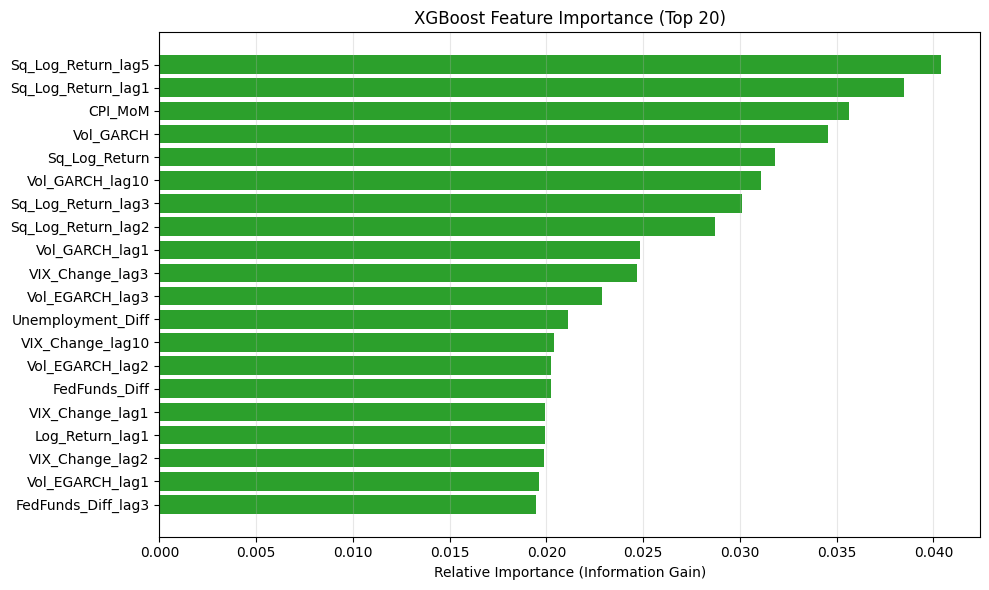

In [3]:
# 4. Look at feature importance from the most mature model fold
models_xgb.plot_feature_importance(final_model, feature_names)

In [4]:
# 03_baseline_xgboost.ipynb
from src.src_bak import data_loader, features, volatility, regimes, models_xgb
import pandas as pd

# 1. Standard Data Ingest & Math
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)
garch_df = volatility.generate_expanding_garch(stat_df)

# 2. Generate the 4-State HMM
print("\n--- Generating HMM Targets ---")
hmm_4_df = regimes.generate_hmm_targets(garch_df, feature_cols=['Log_Return', 'Vol_EGARCH'], n_components=4)

# 3. Safe Merge & Mapping to 3 ML Classes
master_df = garch_df.copy()
master_df['Target_HMM'] = hmm_4_df['Target_HMM']
master_df = master_df.dropna(subset=['Target_HMM'])

# Collapse the two lowest volatility states into Class 0 (Calm)
mapping_dict = {
    0: 0,  # Dead Calm -> Calm
    1: 0,  # Normal -> Calm
    2: 1,  # Elevated
    3: 2   # Shock
}
master_df['Target_HMM_ML'] = master_df['Target_HMM'].map(mapping_dict).astype(int)
master_df = master_df.drop('Target_HMM', axis=1)

# 4. Lag Engineering for XGBoost
cols_to_lag = [
    'Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
    'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff'
]
final_df = features.create_lags(master_df, feature_cols=cols_to_lag)

# 5. Walk-Forward Validation
# We pass our newly mapped HMM column as the target
final_model, feature_names = models_xgb.train_xgb_walk_forward(
    df=final_df, 
    target_col='Target_HMM_ML', 
    n_splits=4
)

Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating Industry Standard GARCH & EGARCH (Window: 252, Refit: 21 days)...


Out-of-sample GARCH/EGARCH generation complete.

--- Generating HMM Targets ---

--- HMM Generation Process ---


HMM State 0 Average Volatility: 0.0155
HMM State 1 Average Volatility: 0.1998
HMM State 2 Average Volatility: 0.0058
HMM State 3 Average Volatility: 0.0473
Mapping Order (Lowest Vol to Highest Vol): [2, 0, 3, 1]
HMM Target generation complete. Shape: (6227, 1)

Generating lag features for: [1, 2, 3, 5, 10] days...
Starting expanding-window Walk-Forward Validation (4 splits)...

--- Fold 1 ---
  Training on index 0 to 1243 (Samples: 1243)
  Testing on index 1243 to 2486 (Samples: 1243)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.98      0.97      0.97       973
Class 1 (Elevated)       0.88      0.95      0.91       213
   Class 2 (Shock)       0.89      0.74      0.81        57

          accuracy                           0.96      1243
         macro avg       0.92      0.89      0.90      1243
      weighted avg       0.96      0.96      0.96      1243


--- Fold 2 ---
  Training on index 0 to 2486 (Samples: 2486)
  Testing on index 2486 to 3729 (Samples: 1243)


                    precision    recall  f1-score   support

    Class 0 (Calm)       1.00      1.00      1.00      1180
Class 1 (Elevated)       0.97      0.97      0.97        63
   Class 2 (Shock)       0.00      0.00      0.00         0

          accuracy                           1.00      1243
         macro avg       0.66      0.66      0.66      1243
      weighted avg       1.00      1.00      1.00      1243


--- Fold 3 ---
  Training on index 0 to 3729 (Samples: 3729)
  Testing on index 3729 to 4972 (Samples: 1243)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.99      0.98      0.98      1035
Class 1 (Elevated)       0.89      0.92      0.90       188
   Class 2 (Shock)       0.86      0.90      0.88        20

          accuracy                           0.97      1243
         macro avg       0.91      0.93      0.92      1243
      weighted avg       0.97      0.97      0.97      1243


--- Fold 4 ---
  Training on index 0 to 4972 (Samples: 4972)
  Testing on index 4972 to 6217 (Samples: 1245)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.98      0.98      0.98      1044
Class 1 (Elevated)       0.91      0.88      0.89       170
   Class 2 (Shock)       0.91      0.94      0.92        31

          accuracy                           0.97      1245
         macro avg       0.93      0.93      0.93      1245
      weighted avg       0.97      0.97      0.97      1245


AGGREGATED WALK-FORWARD PERFORMANCE REPORT
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.99      0.98      0.98      4232
Class 1 (Elevated)       0.90      0.92      0.91       634
   Class 2 (Shock)       0.89      0.82      0.86       108

          accuracy                           0.97      4974
         macro avg       0.92      0.91      0.92      4974
      weighted avg       0.97      0.97      0.97      4974



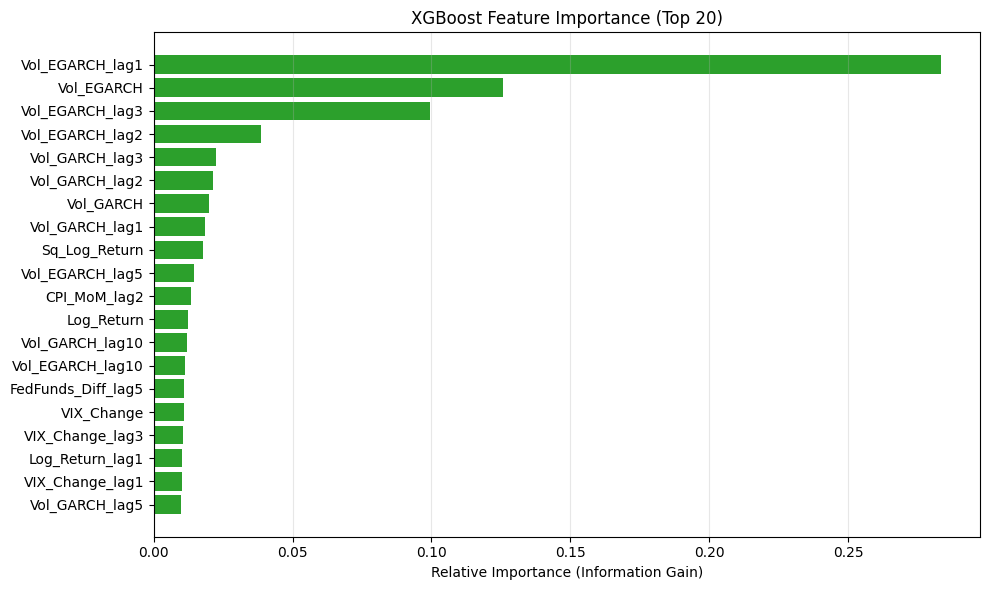

In [5]:
# 6. Plot the Final Feature Importance
models_xgb.plot_feature_importance(final_model, feature_names)